# Assistant d'aide a l'analyse juridique en droit administratif

## Notebook principal du projet

Ce notebook est le support principal du projet. Il presente de facon complete la demarche suivie :

1. definition du use case
2. choix et exploration des donnees
3. feature engineering
4. modelisation avec trois approches
5. evaluation, erreurs et robustesse
6. choix du modele final
7. articulation avec l'application Streamlit

Le perimetre est volontairement limite au **droit administratif francais** afin de garder un projet coherent, defendable et base sur des donnees officielles.

## 1. Use case

Le projet vise un besoin metier simple : **qualifier rapidement un dossier administratif a partir d'un resume de faits**.

L'outil ne remplace pas un avocat. Il fournit une aide de triage initial pour repondre a des questions comme :

- est-ce bien du droit administratif ?
- a quelle grande famille de recours cela ressemble-t-il ?
- vers quel type de specialiste faut-il orienter le dossier ?
- existe-t-il des decisions proches dans le corpus ?

Le projet est donc un **systeme de machine learning applique au triage juridique administratif**.

## 2. Pourquoi ce perimetre et pas tout le droit francais ?

Couvrir l'ensemble du droit francais aurait conduit a un projet trop large et peu rigoureux : jeux de donnees heterogenes, classes mal definies, comportements metier trop differents.

Le choix du droit administratif est methodologiquement plus solide car il permet de travailler sur :

- un corpus officiel et accessible,
- des decisions reelles de justice,
- une structure procedurale exploitable,
- une classification en grandes familles de recours defendable.

## 3. Source des donnees

Le dataset principal utilise est `data/processed_legal_cases_admin.csv`.

Il provient d'un travail de transformation d'un corpus de decisions administratives francaises en table exploitable pour le machine learning.

Pourquoi cette source est pertinente :

- source officielle,
- vraies decisions de justice,
- metadonnees juridiques exploitables,
- coherence avec le perimetre choisi.

Variables importantes :

- `facts_summary` : resume textuel des faits,
- `case_category` : cible principale a predire,
- `likely_outcome` : issue simplifiee observee,
- `type_decision`, `type_recours`, `solution`, `date_lecture`, `source_prefix` : metadonnees de lecture du corpus.

In [15]:
from pathlib import Path
import sys

import joblib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

from IPython.display import display
from scipy.sparse import hstack
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_recall_fscore_support, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import Normalizer, StandardScaler

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from config import PROCESSED_DATA_FILE, MODELS, RANDOM_STATE, TEST_SIZE, TEXT_COLUMN, TARGET_COLUMN, OUTCOME_COLUMN
from features import LegalSignalTransformer
from app import _find_similar_jurisprudence, _load_reference_metadata, _triage_case

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 220)
PROJECT_ROOT

PosixPath('/Users/theodorelemolgat/Desktop/Projet final S2 ML')

In [16]:
CATEGORY_LABELS = {
    'plein_contentieux': 'Plein contentieux',
    'exces_de_pouvoir': 'Recours pour exces de pouvoir',
    'autres_recours': 'Autres recours administratifs',
}

OUTCOME_LABELS = {
    'defavorable_requerant': 'Defavorable au requerant',
    'favorable_requerant': 'Favorable au requerant',
    'partiellement_favorable': 'Partiellement favorable',
    'desistement': 'Desistement',
    'renvoi': 'Renvoi',
    'non_lieu': 'Non-lieu',
    'autre_issue': 'Autre issue',
}

def humanize_category(value):
    return CATEGORY_LABELS.get(value, value)

def humanize_outcome(value):
    return OUTCOME_LABELS.get(value, value)

In [17]:
df = pd.read_csv(PROCESSED_DATA_FILE)
df.head(3)

,facts_summary,case_category,likely_outcome,source_file,source_prefix,date_lecture,type_decision,type_recours,solution,text_length
0,"La Fédération CFDT des banques et assurances, Mme D B, Mme M E épouse O, Mme L N épouse H, Mme J F épouse A, Mme G I et M. K C ont demandé au tribunal administratif de Paris d'annuler pour excès de pouvoir la décisio...",exces_de_pouvoir,defavorable_requerant,DCE_434225_20220601.xml,DCE,2022-06-01,Décision,Excès de pouvoir,Rejet,18131
1,"M. B A a demandé au tribunal administratif de Lille d'annuler pour excès de pouvoir la décision du 28 mai 2015 par laquelle la ministre du travail, de l'emploi, de la formation professionnelle et du dialogue social a...",exces_de_pouvoir,favorable_requerant,DCE_435266_20220620.xml,DCE,2022-06-20,Décision,Excès de pouvoir,Satisfaction totale,10001
2,"Par une décision du 30 décembre 2020, le Conseil d’Etat, statuant au contentieux, a prononcé l’admission des conclusions du pourvoi de la société Immotour dirigées contre l’arrêt n°s 18NC02355, 18NC02356, 18NC02508 d...",plein_contentieux,partiellement_favorable,DCE_437160_20220613.xml,DCE,2022-06-13,Décision,Plein contentieux,Satisfaction partielle,8347


## 4. Vue d'ensemble du dataset

In [18]:
df.shape

(743, 10)

In [19]:
df.columns.tolist()

['facts_summary',
 'case_category',
 'likely_outcome',
 'source_file',
 'source_prefix',
 'date_lecture',
 'type_decision',
 'type_recours',
 'solution',
 'text_length']

In [20]:
df.dtypes

facts_summary     object
case_category     object
likely_outcome    object
source_file       object
source_prefix     object
date_lecture      object
type_decision     object
type_recours      object
solution          object
text_length        int64
dtype: object

## 5. Qualite des donnees

Avant toute modelisation, il faut verifier que le corpus est suffisamment propre : valeurs manquantes, doublons, variables exploitables.

In [21]:
missing_df = pd.DataFrame({
    'column': df.columns,
    'missing_count': [int(df[col].isna().sum()) for col in df.columns],
    'missing_ratio_pct': [round(float(df[col].isna().mean() * 100), 2) for col in df.columns],
    'n_unique': [int(df[col].nunique(dropna=True)) for col in df.columns],
}).sort_values(['missing_count', 'n_unique'], ascending=[False, False])
missing_df

,column,missing_count,missing_ratio_pct,n_unique
8,solution,1,0.13,39
0,facts_summary,0,0.00,743
3,source_file,0,0.00,743
9,text_length,0,0.00,665
5,date_lecture,0,0.00,22
7,type_recours,0,0.00,11
2,likely_outcome,0,0.00,7
1,case_category,0,0.00,3
4,source_prefix,0,0.00,2
6,type_decision,0,0.00,2


In [22]:
duplicate_source_files = int(df.duplicated(subset=['source_file']).sum())
duplicate_source_files

0

## 6. Profil global du corpus

On calcule ici quelques indicateurs de base pour caracteriser rapidement le dataset.

In [23]:
profile_df = pd.DataFrame({
    'indicateur': [
        'nombre_de_decisions',
        'nombre_de_colonnes',
        'periode_min',
        'periode_max',
        'longueur_mediane_resume',
        'longueur_moyenne_resume',
        'categorie_majoritaire',
        'issue_majoritaire',
        'prefixe_source_majoritaire',
    ],
    'valeur': [
        len(df),
        df.shape[1],
        df['date_lecture'].dropna().astype(str).min(),
        df['date_lecture'].dropna().astype(str).max(),
        int(df['text_length'].median()),
        round(float(df['text_length'].mean()), 1),
        humanize_category(df[TARGET_COLUMN].value_counts().index[0]),
        humanize_outcome(df[OUTCOME_COLUMN].value_counts().index[0]),
        df['source_prefix'].value_counts().index[0],
    ],
})
profile_df

,indicateur,valeur
0,nombre_de_decisions,743
1,nombre_de_colonnes,10
2,periode_min,2022-06-01
3,periode_max,2022-06-30
4,longueur_mediane_resume,3947
5,longueur_moyenne_resume,5744.3
6,categorie_majoritaire,Plein contentieux
7,issue_majoritaire,Defavorable au requerant
8,prefixe_source_majoritaire,DCE


## 7. Definition de la cible et strategie de labels

La cible `case_category` est une version simplifiee de familles de contentieux administratif plus fines.

Le choix de trois classes a ete retenu pour garder un schema lisible et defendable :

- `plein_contentieux`
- `exces_de_pouvoir`
- `autres_recours`

Le tableau ci-dessous relie la variable procedurale `type_recours` aux labels finaux.

In [24]:
pd.crosstab(df['type_recours'], df[TARGET_COLUMN]).sort_index()

case_category,autres_recours,exces_de_pouvoir,plein_contentieux
type_recours,,,
Appréciation de la légalité,2,0,0
Autres,9,0,0
Contentieux des pensions,7,0,0
Excès de pouvoir,0,344,0
Exécution,1,0,0
MAGIERA,1,0,0
Plein contentieux,0,0,370
Recours en interprétation,1,0,0
Recours en révision,5,0,0


## 8. Distribution de la variable cible

In [25]:
category_counts = df[TARGET_COLUMN].value_counts().rename_axis('categorie').reset_index(name='count')
category_counts['categorie_lisible'] = category_counts['categorie'].map(humanize_category)
category_counts['share_pct'] = (category_counts['count'] / len(df) * 100).round(1)
category_counts

,categorie,count,categorie_lisible,share_pct
0,plein_contentieux,370,Plein contentieux,49.8
1,exces_de_pouvoir,344,Recours pour exces de pouvoir,46.3
2,autres_recours,29,Autres recours administratifs,3.9


In [26]:
fig = px.bar(
    category_counts.sort_values('count'),
    x='count',
    y='categorie_lisible',
    orientation='h',
    text='share_pct',
    title='Distribution des familles de recours',
)
fig.update_traces(texttemplate='%{text}%')
fig.update_layout(template='plotly_white', height=360, xaxis_title='Nombre de decisions', yaxis_title='')
fig.show()

### Complément Seaborn

On ajoute ici une visualisation `seaborn` plus classique, utile dans un notebook orienté data science et facile à commenter à l'oral.


/var/folders/mn/hrq9rwj1069_800lbx6tc_500000gn/T/ipykernel_61251/1123098908.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


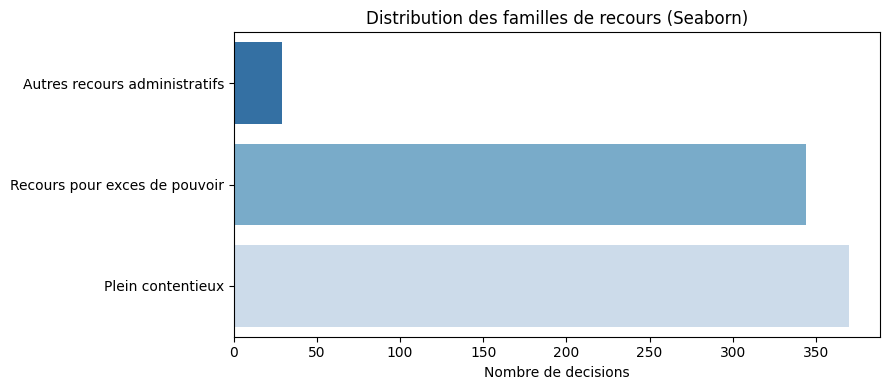

In [27]:
import seaborn as sns

plt.figure(figsize=(9, 4))
sns.barplot(
    data=category_counts.sort_values('count', ascending=True),
    x='count',
    y='categorie_lisible',
    palette='Blues_r',
)
plt.title('Distribution des familles de recours (Seaborn)')
plt.xlabel('Nombre de decisions')
plt.ylabel('')
plt.tight_layout()
plt.show()


## 9. Distribution des issues observees

In [28]:
outcome_counts = df[OUTCOME_COLUMN].value_counts().rename_axis('issue').reset_index(name='count')
outcome_counts['issue_lisible'] = outcome_counts['issue'].map(humanize_outcome)
outcome_counts['share_pct'] = (outcome_counts['count'] / len(df) * 100).round(1)
outcome_counts.head(10)

,issue,count,issue_lisible,share_pct
0,defavorable_requerant,573,Defavorable au requerant,77.1
1,renvoi,66,Renvoi,8.9
2,desistement,42,Desistement,5.7
3,partiellement_favorable,19,Partiellement favorable,2.6
4,autre_issue,18,Autre issue,2.4
5,non_lieu,14,Non-lieu,1.9
6,favorable_requerant,11,Favorable au requerant,1.5


In [29]:
fig = px.bar(
    outcome_counts.head(7).sort_values('count'),
    x='count',
    y='issue_lisible',
    orientation='h',
    text='share_pct',
    title='Issues observees les plus frequentes',
)
fig.update_traces(texttemplate='%{text}%')
fig.update_layout(template='plotly_white', height=400, xaxis_title='Nombre de decisions', yaxis_title='')
fig.show()

### Complément Seaborn

Ce second graphe reprend les issues les plus fréquentes avec une lecture visuelle plus sobre, centrée sur la hiérarchie des fréquences.


/var/folders/mn/hrq9rwj1069_800lbx6tc_500000gn/T/ipykernel_61251/4074034740.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


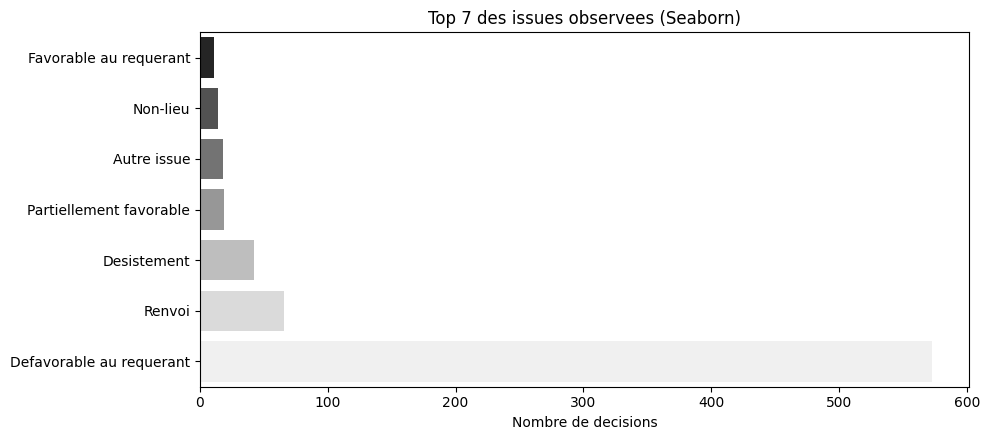

In [30]:
outcome_top7 = outcome_counts.head(7).sort_values('count', ascending=True).copy()
plt.figure(figsize=(10, 4.5))
sns.barplot(
    data=outcome_top7,
    x='count',
    y='issue_lisible',
    palette='Greys_r',
)
plt.title('Top 7 des issues observees (Seaborn)')
plt.xlabel('Nombre de decisions')
plt.ylabel('')
plt.tight_layout()
plt.show()


## 10. Metadonnees juridiques du corpus

On regarde ici des variables plus structurelles pour mieux comprendre le contenu du corpus.

In [31]:
df['type_decision'].value_counts(dropna=False).rename_axis('type_decision').reset_index(name='count')

,type_decision,count
0,Décision,475
1,Ordonnance,268


In [32]:
df['type_recours'].value_counts(dropna=False).head(12).rename_axis('type_recours').reset_index(name='count')

,type_recours,count
0,Plein contentieux,370
1,Excès de pouvoir,344
2,Autres,9
3,Contentieux des pensions,7
4,Recours en révision,5
5,Appréciation de la légalité,2
6,Rectif. d'erreur matérielle,2
7,MAGIERA,1
8,Exécution,1
9,Recours en interprétation,1


In [33]:
df['solution'].value_counts(dropna=False).head(12).rename_axis('solution').reset_index(name='count')

,solution,count
0,Rejet PAPC,232
1,R.822-5 Rejet PAPC défaut ministère avocat,162
2,Rejet,108
3,Renvoi après cassation,65
4,Satisfaction partielle,19
5,R.822-5 Rejet PAPC pourvoi non fondé,19
6,R.822-5 Désistement PAPC,18
7,R. 122-12-1 Désistement,13
8,R. 122-12-4 Rejet irrecevabilité manifeste,13
9,R.822-5-3 Rejet PAPC référé,12


In [34]:
df['source_prefix'].value_counts(dropna=False).rename_axis('source_prefix').reset_index(name='count')

,source_prefix,count
0,DCE,475
1,ORCE,268


## 11. Longueur des resumes de faits

In [35]:
df['text_length'].describe().round(1)

count      743.0
mean      5744.3
std       4504.0
min       1708.0
25%       3180.5
50%       3947.0
75%       6604.5
max      44310.0
Name: text_length, dtype: float64

In [36]:
length_by_category = df.groupby(TARGET_COLUMN)['text_length'].agg(['count', 'mean', 'median', 'min', 'max']).round(1)
length_by_category

,count,mean,median,min,max
case_category,,,,,
autres_recours,29,6718.8,4331.0,2081,24974
exces_de_pouvoir,344,6443.3,4128.0,1708,44310
plein_contentieux,370,5017.9,3636.0,2150,24839


In [37]:
fig = px.histogram(df, x='text_length', nbins=30, title='Distribution globale de la longueur des resumes')
fig.update_layout(template='plotly_white', height=360, xaxis_title='Nombre de caracteres', yaxis_title='Nombre de decisions')
fig.show()

### Complément Seaborn

Cette version avec `histplot` et courbe KDE aide à lire la forme globale de la distribution des longueurs de résumés.


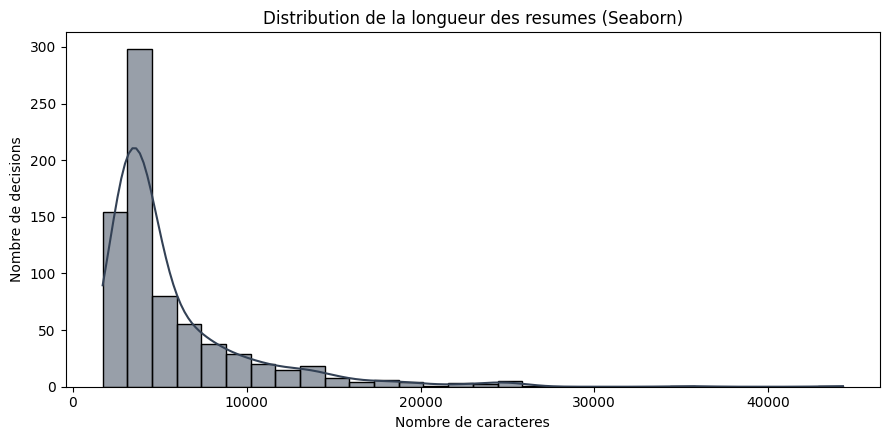

In [38]:
plt.figure(figsize=(9, 4.5))
sns.histplot(data=df, x='text_length', bins=30, kde=True, color='#334155')
plt.title('Distribution de la longueur des resumes (Seaborn)')
plt.xlabel('Nombre de caracteres')
plt.ylabel('Nombre de decisions')
plt.tight_layout()
plt.show()


In [39]:
fig = px.box(df, x='text_length', y=TARGET_COLUMN, color=TARGET_COLUMN, title='Longueur des resumes par categorie')
fig.update_layout(template='plotly_white', height=420, showlegend=False, xaxis_title='Nombre de caracteres', yaxis_title='Categorie')
fig.show()

### Complément Seaborn

On garde aussi une lecture par catégorie via `boxplot`, qui aide à comparer médianes, dispersion et outliers entre familles de recours.


/var/folders/mn/hrq9rwj1069_800lbx6tc_500000gn/T/ipykernel_61251/4229359843.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


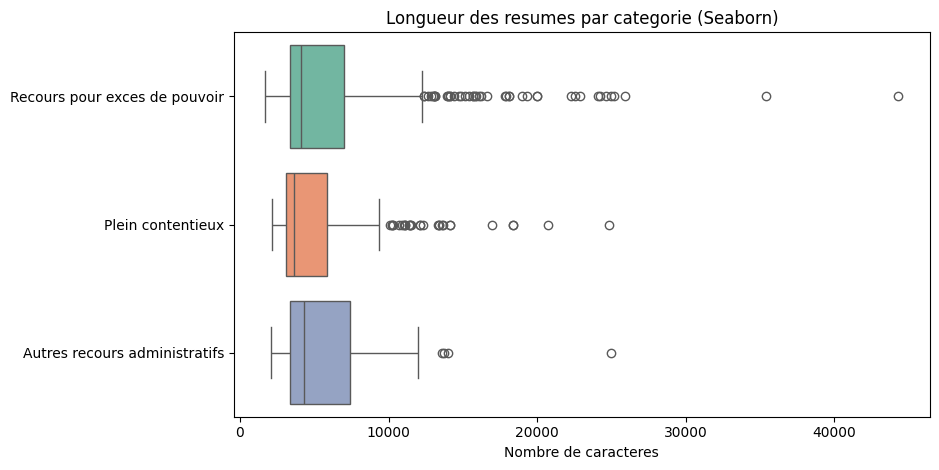

In [40]:
length_plot_df = df.copy()
length_plot_df['categorie_lisible'] = length_plot_df[TARGET_COLUMN].map(humanize_category)
plt.figure(figsize=(9.5, 4.8))
sns.boxplot(
    data=length_plot_df,
    x='text_length',
    y='categorie_lisible',
    palette='Set2',
    orient='h',
)
plt.title('Longueur des resumes par categorie (Seaborn)')
plt.xlabel('Nombre de caracteres')
plt.ylabel('')
plt.tight_layout()
plt.show()


## 12. Croisement categorie / issue observee

In [41]:
outcome_crosstab = pd.crosstab(df[TARGET_COLUMN], df[OUTCOME_COLUMN])
outcome_crosstab

likely_outcome,autre_issue,defavorable_requerant,desistement,favorable_requerant,non_lieu,partiellement_favorable,renvoi
case_category,,,,,,,
autres_recours,7,16,1,0,1,3,1
exces_de_pouvoir,7,256,32,7,11,12,19
plein_contentieux,4,301,9,4,2,4,46


In [42]:
fig = go.Figure(data=go.Heatmap(
    z=outcome_crosstab.values,
    x=outcome_crosstab.columns.tolist(),
    y=outcome_crosstab.index.tolist(),
    text=outcome_crosstab.values,
    texttemplate='%{text}',
    colorscale='Blues'
))
fig.update_layout(template='plotly_white', height=420, title='Croisement categorie / issue observee', xaxis_title='Issue', yaxis_title='Categorie')
fig.show()

### Complément Seaborn

Ici on normalise par ligne pour mieux voir, à l'intérieur de chaque catégorie, quelles issues dominent proportionnellement.


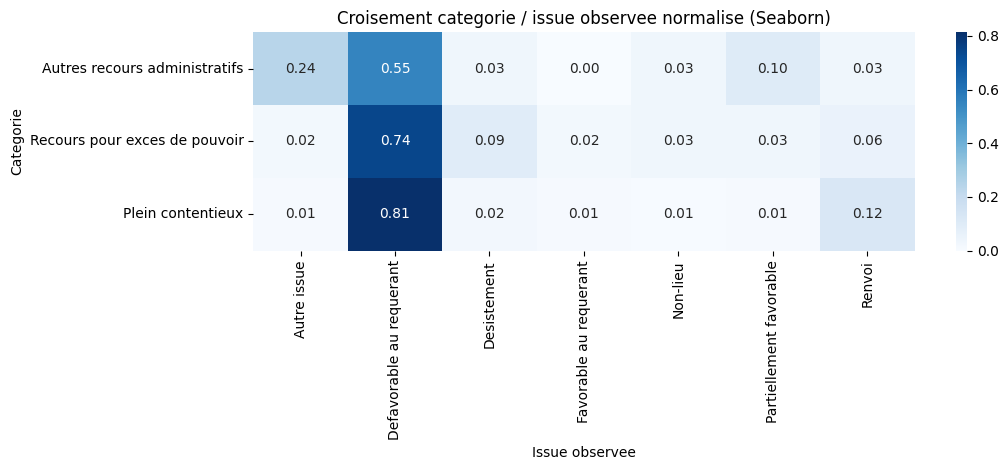

In [43]:
outcome_heatmap_df = outcome_crosstab.div(outcome_crosstab.sum(axis=1), axis=0).copy()
outcome_heatmap_df.index = [humanize_category(value) for value in outcome_heatmap_df.index]
outcome_heatmap_df.columns = [humanize_outcome(value) for value in outcome_heatmap_df.columns]
plt.figure(figsize=(11, 4.8))
sns.heatmap(outcome_heatmap_df, annot=True, fmt='.2f', cmap='Blues')
plt.title('Croisement categorie / issue observee normalise (Seaborn)')
plt.xlabel('Issue observee')
plt.ylabel('Categorie')
plt.tight_layout()
plt.show()


## 13. Exemples typiques par categorie

In [44]:
def build_typical_examples(frame):
    rows = []
    for category in frame[TARGET_COLUMN].value_counts().index.tolist():
        subset = frame[frame[TARGET_COLUMN] == category].copy()
        subset['distance_to_median'] = (subset['text_length'] - subset['text_length'].median()).abs()
        row = subset.sort_values('distance_to_median').iloc[0]
        rows.append({
            'categorie': humanize_category(category),
            'likely_outcome': humanize_outcome(row[OUTCOME_COLUMN]),
            'facts_summary_excerpt': str(row[TEXT_COLUMN])[:320] + '...',
        })
    return pd.DataFrame(rows)

typical_examples_df = build_typical_examples(df)
typical_examples_df

,categorie,likely_outcome,facts_summary_excerpt
0,Plein contentieux,Defavorable au requerant,Mme A B a demandé à la Cour nationale du droit d'asile d'annuler la décision du 27 août 2019 par laquelle l'Office français de protection des réfugiés et apatrides a rejeté sa demande d'asile. Par une décision n° 190...
1,Recours pour exces de pouvoir,Defavorable au requerant,M. A B a demandé au tribunal administratif de Paris de condamner l'Etat à lui verser la somme de 198 000 euros en réparation des préjudices qu'il a subis du fait de la loi n° 2014-1104 du 1er octobre 2014 relative au...
2,Autres recours administratifs,Defavorable au requerant,Procédure contentieuse antérieure : M. A B a demandé au tribunal administratif de Nantes d'annuler la décision du 30 octobre 2017 par laquelle le greffier en chef du tribunal d'instance de Juvisy-sur-Orge a refusé de...


## 14. Top termes par categorie

Cette section ajoute une lecture textuelle du corpus en identifiant les termes les plus representatifs de chaque classe.

In [45]:
def top_terms_by_category(frame, category, top_n=12):
    subset = frame[frame[TARGET_COLUMN] == category][TEXT_COLUMN].astype(str)
    vectorizer = TfidfVectorizer(ngram_range=(1, 1), min_df=2, max_df=0.95)
    matrix = vectorizer.fit_transform(subset)
    scores = np.asarray(matrix.mean(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()
    order = scores.argsort()[::-1][:top_n]
    return pd.DataFrame({'term': terms[order], 'mean_tfidf': scores[order].round(4)})

for category in df[TARGET_COLUMN].value_counts().index.tolist():
    print('\n###', humanize_category(category))
    display(top_terms_by_category(df, category, top_n=12))


### Plein contentieux


,term,mean_tfidf
0,asile,0.0881
1,des,0.0801
2,2021,0.0785
3,décision,0.0737
4,cour,0.0700
5,une,0.0687
6,rejeté,0.0681
7,droit,0.0675
8,2022,0.0626
9,ordonnance,0.0625



### Recours pour exces de pouvoir


,term,mean_tfidf
0,et,0.1184
1,un,0.0857
2,des,0.0797
3,demande,0.0587
4,2021,0.0554
5,mme,0.0539
6,tribunal,0.0536
7,en,0.0524
8,2022,0.0521
9,administrative,0.0509



### Autres recours administratifs


,term,mean_tfidf
0,et,0.1332
1,des,0.1104
2,un,0.1044
3,une,0.1020
4,ordonnance,0.0842
5,rejeté,0.0773
6,en,0.0759
7,2021,0.0758
8,mme,0.0740
9,2022,0.0729


## 15. Feature engineering

Le projet ne repose pas seulement sur du texte brut.

La strategie de features est la suivante :

1. **Baseline textuelle** : TF-IDF mots avec unigrams + bigrams
2. **Signaux juridiques explicites** : refus, annulation, prefecture, titre de sejour, fiscalite, indemnisation, urgence, etc.
3. **Representation dense reduite** : TF-IDF + TruncatedSVD pour les modeles non lineaires

Pourquoi :

- la regression logistique fonctionne tres bien sur des features creuses
- random forest et MLP ont besoin d'une representation dense plus compacte
- les signaux juridiques explicites ajoutent de la pertinence metier et de l'interpretabilite

In [46]:
clean_df = df.dropna(subset=[TEXT_COLUMN, TARGET_COLUMN]).copy()
clean_df[TEXT_COLUMN] = clean_df[TEXT_COLUMN].astype(str).str.strip()
clean_df = clean_df[clean_df[TEXT_COLUMN] != '']
X = clean_df[TEXT_COLUMN]
y = clean_df[TARGET_COLUMN]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
X_train.shape, X_test.shape

((557,), (186,))

**Lecture de cette cellule**  
Cette cellule prépare le corpus utilisé pour la modélisation : suppression des valeurs manquantes, nettoyage des textes vides, puis séparation en **train/test stratifié**.  
Le split stratifié conserve la proportion des 3 classes cibles dans les deux sous-ensembles, ce qui rend la comparaison des modèles plus fiable.


In [47]:
tfidf_demo = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)
X_tfidf_train = tfidf_demo.fit_transform(X_train)
X_tfidf_train.shape

(557, 7459)

**Lecture de cette cellule**  
Cette cellule construit la représentation **TF-IDF mots** du jeu d'entraînement avec des **unigrams + bigrams**.  
La forme de la matrice correspond à : **nombre de dossiers d'entraînement x taille du vocabulaire retenu**. C'est la base textuelle principale du modèle linéaire.


In [48]:
signal_transformer = LegalSignalTransformer()
X_signal_train = signal_transformer.fit_transform(X_train, y_train)
signal_feature_names = signal_transformer.get_feature_names_out().tolist()
X_signal_train.shape, signal_feature_names

((557, 18),
 ['signal_log_tokens',
  'signal_log_chars',
  'signal_ratio_digits',
  'signal_annulation',
  'signal_decision_administrative',
  'signal_immigration',
  'signal_autorite_publique',
  'signal_financier',
  'signal_fiscal',
  'signal_indemnitaire',
  'signal_social',
  'signal_contrat_public',
  'signal_urgence',
  'signal_renvoi_procedural',
  'signal_juridiction_externe',
  'signal_score_exces_pouvoir',
  'signal_score_plein_contentieux',
  'signal_score_autres_recours'])

**Lecture de cette cellule**  
Cette cellule construit les **features métier explicites** définies dans `src/features.py`.  
Le résultat contient les signaux juridiques et structurels ajoutés au texte : annulation, décision administrative, immigration, fiscalité, indemnisation, urgence, renvoi procédural, scores agrégés par famille de recours, etc.


In [49]:
svd_demo = TruncatedSVD(n_components=128, random_state=RANDOM_STATE)
normalizer_demo = Normalizer(copy=False)
X_svd_train = normalizer_demo.fit_transform(svd_demo.fit_transform(X_tfidf_train))
X_dense_hybrid_train = np.hstack([X_svd_train, X_signal_train.toarray()])
X_dense_hybrid_train.shape

(557, 146)

**Lecture de cette cellule**  
Cette cellule projette le TF-IDF dans un espace dense de **128 composantes** avec `TruncatedSVD`, puis concatène ces composantes avec les signaux métier.  
C'est cette représentation compacte qui sera utilisée par les modèles non linéaires, car elle est beaucoup plus adaptée que le TF-IDF sparse brut pour `Random Forest` et `MLPClassifier`.


## 16. Definition des 3 modeles

Dans ce projet, on **ne part pas d'un seul modele impose**. La demarche est experimentale :

1. on construit plusieurs representations des donnees,
2. on entraine plusieurs modeles differents,
3. on compare leurs performances sur le meme split train/test,
4. on retient ensuite le meilleur compromis pour l'application finale.

Les 3 modeles compares dans ce notebook sont :

1. **Regression logistique**
   - TF-IDF sparse + signaux juridiques
   - interpretable et tres compatible avec l'app

2. **Random Forest**
   - representation dense reduite + signaux juridiques
   - baseline non lineaire classique

3. **MLPClassifier**
   - representation dense reduite + signaux juridiques + standardisation
   - alternative type deep learning legere, executable dans l'environnement actuel

L'objectif n'est donc pas de "choisir un modele au hasard", mais de **tester plusieurs familles de modeles** puis de justifier objectivement le choix final.


In [50]:
class DenseHybridTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=128, scale_output=False):
        self.n_components = n_components
        self.scale_output = scale_output
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)
        self.svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
        self.normalizer = Normalizer(copy=False)
        self.signal_transformer = LegalSignalTransformer()
        self.scaler = StandardScaler()

    def fit(self, X, y=None):
        X_tfidf = self.vectorizer.fit_transform(X)
        X_dense = self.normalizer.fit_transform(self.svd.fit_transform(X_tfidf))
        X_signals = self.signal_transformer.fit(X, y).transform(X).toarray()
        if self.scale_output:
            self.scaler.fit(np.hstack([X_dense, X_signals]))
        return self

    def transform(self, X):
        X_tfidf = self.vectorizer.transform(X)
        X_dense = self.normalizer.transform(self.svd.transform(X_tfidf))
        X_signals = self.signal_transformer.transform(X).toarray()
        X_all = np.hstack([X_dense, X_signals])
        if self.scale_output:
            return self.scaler.transform(X_all)
        return X_all


log_reg_model = Pipeline([
    ('features', FeatureUnion([
        ('word_tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)),
        ('signals', LegalSignalTransformer()),
    ])),
    ('classifier', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE, class_weight='balanced')),
])

random_forest_model = Pipeline([
    ('features', DenseHybridTransformer(n_components=128, scale_output=False)),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

mlp_model = Pipeline([
    ('features', DenseHybridTransformer(n_components=128, scale_output=True)),
    ('classifier', MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=500,
        early_stopping=False,
        random_state=RANDOM_STATE,
    )),
])

model_registry = {
    'logistic_regression': log_reg_model,
    'random_forest': random_forest_model,
    'mlp_classifier': mlp_model,
}
list(model_registry.keys())

['logistic_regression', 'random_forest', 'mlp_classifier']

## 17. Entrainement des modeles

Tous les modeles sont entraines sur le **meme split train/test** afin de garder une comparaison equitable.

In [51]:
trained_models = {}
for model_name, model in model_registry.items():
    model.fit(X_train, y_train)
    trained_models[model_name] = model

list(trained_models.keys())

['logistic_regression', 'random_forest', 'mlp_classifier']

## 18. Evaluation globale

In [52]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    return {
        'model_name': model_name,
        'train_accuracy': accuracy_score(y_train, train_pred),
        'test_accuracy': accuracy_score(y_test, test_pred),
        'train_f1_macro': f1_score(y_train, train_pred, average='macro', zero_division=0),
        'test_f1_macro': f1_score(y_test, test_pred, average='macro', zero_division=0),
        'test_precision_macro': precision_score(y_test, test_pred, average='macro', zero_division=0),
        'test_recall_macro': recall_score(y_test, test_pred, average='macro', zero_division=0),
    }

evaluation_rows = [evaluate_model(name, model, X_train, X_test, y_train, y_test) for name, model in trained_models.items()]
evaluation_df = pd.DataFrame(evaluation_rows).sort_values('test_f1_macro', ascending=False)
evaluation_df_rounded = evaluation_df.copy()
for column in evaluation_df_rounded.columns[1:]:
    evaluation_df_rounded[column] = (evaluation_df_rounded[column] * 100).round(1)
evaluation_df_rounded

,model_name,train_accuracy,test_accuracy,train_f1_macro,test_f1_macro,test_precision_macro,test_recall_macro
0,logistic_regression,93.9,88.7,93.8,83.4,83.4,83.4
2,mlp_classifier,99.8,87.1,99.9,78.4,91.4,73.3
1,random_forest,99.8,87.1,99.9,67.3,91.3,64.7


In [53]:
fig = px.bar(
    evaluation_df_rounded.sort_values('test_f1_macro'),
    x='test_f1_macro',
    y='model_name',
    orientation='h',
    title='Comparaison des 3 modeles sur le F1 macro',
)
fig.update_layout(template='plotly_white', height=380, xaxis_title='F1 macro (%)', yaxis_title='')
fig.show()

## 19. Choix du modele final

Apres avoir **teste et compare plusieurs modeles**, le modele final retenu est la **regression logistique hybride**.

Le choix final ne repose pas sur une intuition, mais sur une lecture combinee de plusieurs criteres :

- performance globale sur le jeu de test,
- robustesse,
- interpretabilite,
- compatibilite avec l'application Streamlit actuelle.

Dans notre cas, la regression logistique hybride est retenue car elle offre le meilleur compromis :

- meilleure performance globale sur ce corpus,
- bonne robustesse,
- interpretabilite superieure,
- compatibilite directe avec l'application Streamlit actuelle.

Les modeles Random Forest et MLP restent utiles comme comparateurs non lineaires, mais ils ne justifient pas un remplacement du modele principal.

**Message cle du projet :** nous avons volontairement compare plusieurs modeles avant de choisir celui qui sera utilise dans l'application finale.


In [54]:
selected_model_key = 'logistic_regression'
selected_model = trained_models[selected_model_key]
selected_model_key

'logistic_regression'

## 20. Metriques par classe du modele final

In [55]:
selected_pred = selected_model.predict(X_test)
labels = sorted(y_test.astype(str).unique().tolist())
precision, recall, f1, support = precision_recall_fscore_support(y_test, selected_pred, labels=labels, zero_division=0)
class_metrics_df = pd.DataFrame({
    'case_category': labels,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'support': support,
})
class_metrics_display = class_metrics_df.copy()
class_metrics_display['case_category'] = class_metrics_display['case_category'].map(humanize_category)
for column in ['precision', 'recall', 'f1_score']:
    class_metrics_display[column] = (class_metrics_display[column] * 100).round(1)
class_metrics_display

,case_category,precision,recall,f1_score,support
0,Autres recours administratifs,71.4,71.4,71.4,7
1,Recours pour exces de pouvoir,85.7,90.7,88.1,86
2,Plein contentieux,93.2,88.2,90.6,93


In [56]:
fig = px.bar(
    class_metrics_display,
    x='case_category',
    y='f1_score',
    color='case_category',
    title='F1 par classe du modele final',
)
fig.update_layout(template='plotly_white', height=380, xaxis_title='Classe', yaxis_title='F1 (%)', showlegend=False)
fig.show()

## 21. Matrice de confusion du modele final

In [57]:
conf_matrix = confusion_matrix(y_test, selected_pred, labels=labels)
conf_df = pd.DataFrame(conf_matrix, index=labels, columns=labels)
conf_df

,autres_recours,exces_de_pouvoir,plein_contentieux
autres_recours,5,2,0
exces_de_pouvoir,2,78,6
plein_contentieux,0,11,82


In [58]:
fig = go.Figure(data=go.Heatmap(
    z=conf_df.values,
    x=[humanize_category(value) for value in conf_df.columns.tolist()],
    y=[humanize_category(value) for value in conf_df.index.tolist()],
    text=conf_df.values,
    texttemplate='%{text}',
    colorscale='Blues',
    hovertemplate='Reel: %{y}<br>Predit: %{x}<br>Nombre: %{z}<extra></extra>',
))
fig.update_layout(template='plotly_white', height=430, title='Matrice de confusion du modele final', xaxis_title='Prediction', yaxis_title='Classe reelle')
fig.show()

## 22. Verification simple du risque d'overfitting

On compare les performances train/test pour verifier qu'il ne s'agit pas simplement d'un modele qui memorise le jeu d'entrainement.

In [59]:
overfit_check_df = evaluation_df_rounded[['model_name', 'train_accuracy', 'test_accuracy', 'train_f1_macro', 'test_f1_macro']].copy()
overfit_check_df

,model_name,train_accuracy,test_accuracy,train_f1_macro,test_f1_macro
0,logistic_regression,93.9,88.7,93.8,83.4
2,mlp_classifier,99.8,87.1,99.9,78.4
1,random_forest,99.8,87.1,99.9,67.3


## 23. Validation croisee

Pour ne pas s'en tenir a un seul split train/test, on ajoute une validation croisee 5-fold.

Elle est lancee ici sur :

- le modele logistique final,
- le Random Forest,
- le MLP.

Cela donne une vision plus stable des performances.

In [60]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for model_name, model in model_registry.items():
    scores = cross_validate(model, X, y, cv=cv, scoring={'accuracy': 'accuracy', 'f1_macro': 'f1_macro'})
    cv_rows.append({
        'model_name': model_name,
        'cv_accuracy_mean': round(scores['test_accuracy'].mean(), 4),
        'cv_accuracy_std': round(scores['test_accuracy'].std(), 4),
        'cv_f1_macro_mean': round(scores['test_f1_macro'].mean(), 4),
        'cv_f1_macro_std': round(scores['test_f1_macro'].std(), 4),
    })
cv_df = pd.DataFrame(cv_rows)
cv_df

,model_name,cv_accuracy_mean,cv_accuracy_std,cv_f1_macro_mean,cv_f1_macro_std
0,logistic_regression,0.8452,0.0304,0.7373,0.0453
1,random_forest,0.8371,0.0235,0.5688,0.0164
2,mlp_classifier,0.8425,0.0400,0.7219,0.0481


## 24. Robustesse aux reformulations

Un mini-benchmark de reformulations a ete constitue dans le projet pour tester la stabilite des predictions quand les faits sont reformules.

In [61]:
benchmark_df = pd.read_csv(PROJECT_ROOT / 'data' / 'admin_robustness_benchmark.csv')
benchmark_df.head()

,case_id,variant_id,expected_category,facts_summary
0,titre_sejour_refus,1,exces_de_pouvoir,La prefecture refuse un titre de sejour et la personne conteste cette decision.
1,titre_sejour_refus,2,exces_de_pouvoir,Un etranger attaque le refus de titre de sejour prononce par la prefecture.
2,titre_sejour_refus,3,exces_de_pouvoir,Le requerant demande l annulation d un refus de sejour pris par l administration.
3,titre_sejour_refus,4,exces_de_pouvoir,Apres un refus de renouvellement de titre de sejour la personne saisit le juge administratif.
4,permis_construire_refus,1,exces_de_pouvoir,Une commune refuse un permis de construire et le proprietaire veut faire annuler cette decision.


In [62]:
def evaluate_on_benchmark(model_name, model, benchmark_df):
    predictions = model.predict(benchmark_df['facts_summary'])
    details_df = benchmark_df.copy()
    details_df['predicted_category'] = predictions
    details_df['is_correct'] = details_df['predicted_category'] == details_df['expected_category']

    if hasattr(model, 'predict_proba'):
        probabilities = model.predict_proba(benchmark_df['facts_summary'])
        details_df['top_probability'] = probabilities.max(axis=1)
    else:
        details_df['top_probability'] = np.nan

    consistency_scores = []
    for _, group_df in details_df.groupby('case_id'):
        modal_count = group_df['predicted_category'].value_counts().max()
        consistency_scores.append(modal_count / len(group_df))

    return {
        'model_name': model_name,
        'accuracy_expected_category': round(float(details_df['is_correct'].mean()), 4),
        'paraphrase_consistency': round(float(sum(consistency_scores) / len(consistency_scores)), 4),
        'mean_top_probability': round(float(details_df['top_probability'].dropna().mean()), 4) if details_df['top_probability'].notna().any() else np.nan,
    }

robustness_rows = [evaluate_on_benchmark(name, model, benchmark_df) for name, model in trained_models.items()]
robustness_notebook_df = pd.DataFrame(robustness_rows)
robustness_display = robustness_notebook_df.copy()
for column in ['accuracy_expected_category', 'paraphrase_consistency', 'mean_top_probability']:
    robustness_display[column] = pd.to_numeric(robustness_display[column], errors='coerce') * 100
robustness_display.round(1)

,model_name,accuracy_expected_category,paraphrase_consistency,mean_top_probability
0,logistic_regression,85.7,85.7,46.6
1,random_forest,57.1,96.4,53.3
2,mlp_classifier,67.9,71.4,92.1


## 25. Interpretation des erreurs

Sur ce corpus, la classe la plus fragile reste `autres_recours`, ce qui est logique : elle est plus petite et plus heterogene.

A l'inverse, `plein_contentieux` et `exces_de_pouvoir` sont plus stables car ils correspondent a des patterns plus frequents et plus lisibles.

In [63]:
error_summary_df = pd.DataFrame({
    'point': [
        'classe_la_plus_forte',
        'classe_la_plus_fragile',
        'principal_risque',
        'pourquoi_autres_recours_est_difficile',
    ],
    'lecture': [
        'plein_contentieux ou exces_de_pouvoir selon le split et les metriques observees',
        'autres_recours',
        'confusion entre familles proches quand le signal textuel est faible',
        'effectif faible et contenu procedurally heterogene',
    ],
})
error_summary_df

,point,lecture
0,classe_la_plus_forte,plein_contentieux ou exces_de_pouvoir selon le split et les metriques observees
1,classe_la_plus_fragile,autres_recours
2,principal_risque,confusion entre familles proches quand le signal textuel est faible
3,pourquoi_autres_recours_est_difficile,effectif faible et contenu procedurally heterogene


## 26. Exemple d'inference avec le modele final

On teste maintenant un cas administratif plausible avec le modele final.

In [64]:
sample_case = 'Un etranger conteste un refus de titre de sejour oppose par la prefecture et demande l annulation de cette decision.'
triage_result = _triage_case(selected_model, sample_case)
triage_result['probability_df']

,case_category,probability
0,exces_de_pouvoir,0.527255
1,autres_recours,0.370979
2,plein_contentieux,0.101766


In [65]:
reference_df = _load_reference_metadata()
_find_similar_jurisprudence(selected_model, clean_df, reference_df, sample_case, top_n=3)

,ECLI,Numero dossier,Date,Juridiction,Categorie,Issue observee,Proximite textuelle (%),Extrait de faits proches
0,ECLI:FR:CESEC:2022:463615.20220603,463615,2022-06-03,Section du Contentieux,Autres recours administratifs,R. 122-12-4 Rejet irrecevabilité manifeste,21.2,"Par une requête, enregistrée le 28 avril 2022 au secrétariat du contentieux du Conseil d'Etat, M. B A doit être regardé comme demandant l'annulation de l'ordonnance n° 461018 du 14 avril 2022 par laquelle le présiden..."
1,ECLI:FR:CESEC:2022:463890.20220603,463890,2022-06-03,Section du Contentieux,Autres recours administratifs,R. 122-12-4 Rejet irrecevabilité manifeste,13.8,"Par une requête, enregistrée le 10 mai 2022 au secrétariat du contentieux du Conseil d'Etat, M. B A demande au Conseil d'Etat de rectifier pour erreur matérielle l'ordonnance n° 460601 du 20 avril 2022 par laquelle l..."
2,ECLI:FR:CECHS:2022:453563.20220630,453563,2022-06-30,Section du Contentieux,Recours pour exces de pouvoir,R. 122-12-3 Non-lieu à statuer,13.0,M. A B a formé une plainte le 21 février 2020 auprès de la Commission nationale de l'informatique et des libertés (CNIL) à la suite de la décision du 11 février 2020 de refus de déréférencement opposée par la société...


## 27. Lecture critique du module de jurisprudences proches

Ce module fonctionne, mais il doit etre presente correctement.

Il ne faut pas le vendre comme un moteur parfait de recherche jurisprudentielle.

Dans l'etat actuel du projet, il s'agit surtout d'un **rapprochement textuel** avec des decisions du corpus, utile pour explorer des cas voisins, mais pas encore d'une vraie similarite juridique experte.

## 28. Integration avec l'application Streamlit

L'application Streamlit constitue la couche produit de demonstration.

Le notebook joue le role de support analytique principal ; l'app joue le role de support de demo.

In [66]:
app_artifacts_df = pd.DataFrame([
    {'artifact': 'data/processed_legal_cases_admin.csv', 'role': 'corpus principal charge par l app'},
    {'artifact': 'models/hybrid_log_reg_legal.joblib', 'role': 'modele principal utilise par l app'},
    {'artifact': 'results/model_metrics.csv', 'role': 'comparaison globale des modeles'},
    {'artifact': 'results/class_metrics.csv', 'role': 'metriques par classe affichees dans l app'},
    {'artifact': 'results/confusion_matrix.csv', 'role': 'matrice de confusion affichee dans l app'},
    {'artifact': 'results/robustness_metrics.csv', 'role': 'lecture robustesse des reformulations'},
])
app_artifacts_df

,artifact,role
0,data/processed_legal_cases_admin.csv,corpus principal charge par l app
1,models/hybrid_log_reg_legal.joblib,modele principal utilise par l app
2,results/model_metrics.csv,comparaison globale des modeles
3,results/class_metrics.csv,metriques par classe affichees dans l app
4,results/confusion_matrix.csv,matrice de confusion affichee dans l app
5,results/robustness_metrics.csv,lecture robustesse des reformulations


In [67]:
launch_streamlit_command = 'cd "{}" && "{}/.venv/bin/python" -m streamlit run src/app.py'.format(PROJECT_ROOT, PROJECT_ROOT)
launch_streamlit_command

'cd "/Users/theodorelemolgat/Desktop/Projet final S2 ML" && "/Users/theodorelemolgat/Desktop/Projet final S2 ML/.venv/bin/python" -m streamlit run src/app.py'

In [68]:
demo_cases_df = pd.DataFrame([
    {
        'case_type': 'exces_de_pouvoir',
        'facts_summary': 'Un etranger conteste un refus de titre de sejour oppose par la prefecture et demande l annulation de cette decision.',
    },
    {
        'case_type': 'plein_contentieux',
        'facts_summary': 'Une societe demande la condamnation de l administration a lui verser une indemnisation apres un prejudice cause par une decision administrative.',
    },
    {
        'case_type': 'hors_perimetre',
        'facts_summary': 'Un salarie conteste son licenciement apres des faits de discrimination dans son entreprise.',
    },
])
demo_cases_df

,case_type,facts_summary
0,exces_de_pouvoir,Un etranger conteste un refus de titre de sejour oppose par la prefecture et demande l annulation de cette decision.
1,plein_contentieux,Une societe demande la condamnation de l administration a lui verser une indemnisation apres un prejudice cause par une decision administrative.
2,hors_perimetre,Un salarie conteste son licenciement apres des faits de discrimination dans son entreprise.


## 29. Forces du projet

Les principaux points forts sont les suivants :

- corpus juridique reel et officiel,
- perimetre coherent,
- EDA substantielle,
- vrai travail de feature engineering,
- comparaison de plusieurs modeles,
- evaluation globale et detaillee,
- prise en compte de la robustesse,
- articulation claire entre notebook analytique et application de demonstration.

## 30. Limites du projet

Les limites doivent etre explicitees clairement :

- le projet couvre seulement le droit administratif,
- il ne predit que trois familles de recours,
- la classe `autres_recours` est la plus difficile,
- le rapprochement de jurisprudence reste surtout textuel,
- l'outil ne remplace pas une qualification humaine.

## 31. Conclusion

Le projet depasse le simple proof of concept car il combine :

- un corpus reel,
- une exploration complete des donnees,
- une modelisation comparative,
- un feature engineering metier,
- une evaluation rigoureuse,
- une integration produit via Streamlit.

La formulation la plus juste pour le presenter est :

> **un projet de machine learning applique au droit administratif francais, visant a assister la qualification initiale d un dossier a partir d un resume de faits.**